# **Exercise - Implement an End to End CNN Model for Image Classification Task**

**1. Load and visualize images from a dataset stored in directories, where each subdirec-
tory represents a class**

Classes found: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


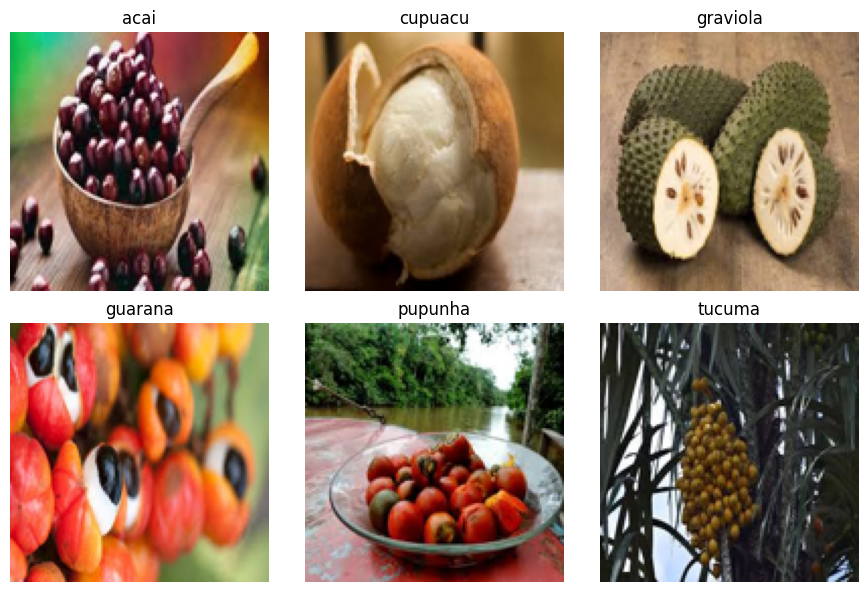

In [15]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

train_dir = "/content/drive/MyDrive/SEM6_AI/Week5/FruitinAmazon/FruitinAmazon/train"
img_width, img_height = 128, 128

class_names = sorted(os.listdir(train_dir))
print("Classes found:", class_names)

images = []
labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    all_images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    random_img_name = random.choice(all_images)
    img_path = os.path.join(class_path, random_img_name)

    img = Image.open(img_path).convert("RGB")
    img = img.resize((img_width, img_height))  # Optional resize
    images.append(np.array(img))
    labels.append(class_name)

num_classes = len(class_names)
cols = (num_classes + 1) // 2  # number of columns
fig, axes = plt.subplots(2, cols, figsize=(3*cols, 6))

for i, ax in enumerate(axes.flat):
    if i < num_classes:
        ax.imshow(images[i])
        ax.set_title(labels[i])
    ax.axis('off')

plt.tight_layout()
plt.show()

**2. Check for Corrupted Image**

In [16]:
corrupted_images = []

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if not os.path.isdir(class_path):
        continue  # skip non-folder files

    for filename in os.listdir(class_path):
        if not filename.lower().endswith(('.jpg','.jpeg','.png')):
            continue

        img_path = os.path.join(class_path, filename)
        try:
            # Try to open the image
            with Image.open(img_path) as img:
                img.verify()  # Verify checks for corruption
        except (IOError, SyntaxError) as e:
            # Image is corrupted → remove and log it
            corrupted_images.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if not corrupted_images:
    print("No corrupted images found.")
else:
    print(f"Total corrupted images removed: {len(corrupted_images)}")

No corrupted images found.


# **Task 2 - Loading and Preprocessing Image Data in keras**

**Interpolation**- When you resize an image, some pixels need to be added or removed to fit the new size (img_height x img_width). Interpolation determines how new pixel values are calculated.

**nearest (Nearest Neighbor Interpolation)**- Each new pixel takes the value of the nearest original pixel.

In [17]:
import tensorflow as tf

# Define image size and batch size
img_height = 128 # Example image height
img_width = 128 # Example image width
batch_size = 32
validation_split = 0.2 # 80% training, 20% validation

# Create a preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255) # Normalize pixel values to [0, 1]

# Create training dataset with normalization
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  train_dir,
  labels='inferred',   # Automatically infers labels from folder names
  label_mode='int',    # Labels will be integers (0,1,2,...)
  image_size=(img_height, img_width),  # Resize all images
  interpolation='nearest',
  batch_size=batch_size,
  shuffle=True,
  validation_split=validation_split,
  subset='training',   # Use the training portion
  seed=123 #ensures that these random operations always produce the same images in training & validation set each time you run the code.
  )

# Apply the normalization (Rescaling) to the dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Create validation dataset with normalization
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  train_dir,
  labels='inferred',
  label_mode='int',
  image_size=(img_height, img_width),
  interpolation='nearest',
  batch_size=batch_size,
  shuffle=False,
  validation_split=validation_split,
  subset='validation',
  seed=123
  )

# Apply the normalization (Rescaling) to the validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


# **Task 3 - Implement a CNN Model**

In [18]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    # --- Convolutional Block 1 ---
    layers.Conv2D(filters=32, kernel_size=(3, 3), padding='same', strides=1,
                  input_shape=(img_height, img_width, 3)),   # input shape: HxWx3 (RGB)
    layers.Activation('relu'),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # --- Convolutional Block 2 ---
    layers.Conv2D(filters=32, kernel_size=(3, 3), padding='same', strides=1),
    layers.Activation('relu'),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # --- Fully Connected Network ---
    layers.Flatten(),                          # Flatten conv output → 1D vector

    layers.Dense(128, activation='relu'),      # Hidden Layer 1: 128 neurons
    layers.Dense(64, activation='relu'),       # Hidden Layer 2: 64 neurons

    layers.Dense(num_classes, activation='softmax')  # Output Layer: one neuron per class
])

# **Task 4 - Compile the Model**

In [19]:
model.compile(optimizer="adam",
  loss="sparse_categorical_crossentropy",
  metrics=["accuracy"])

# **Task 5 - Train the Model**

In [13]:
from tensorflow import keras
epochs = 250

# Rebatch datasets to batch size 16
train_ds = train_ds.rebatch(16)
val_ds = val_ds.rebatch(16)

# Callbacks
callbacks = [
  keras.callbacks.ModelCheckpoint(
    filepath="best_model.keras",   # save the model to this file
    monitor='val_accuracy',        # watch validation accuracy
    save_best_only=True,           # only save if val_accuracy improved
    mode='max',                    # higher val_accuracy = better
),
  keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True,     # go back to best epoch's weights when stopped
    verbose=1
)
]

history = model.fit(
  train_ds,
  epochs=epochs,
  validation_data=val_ds,
  callbacks=callbacks,
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 759ms/step - accuracy: 0.1667 - loss: 2.4329 - val_accuracy: 0.0000e+00 - val_loss: 1.7658
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.2500 - loss: 1.7180 - val_accuracy: 0.2778 - val_loss: 1.6132
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.3750 - loss: 1.5790 - val_accuracy: 0.6667 - val_loss: 1.3084
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.5694 - loss: 1.2836 - val_accuracy: 0.3333 - val_loss: 1.2974
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6528 - loss: 0.9962 - val_accuracy: 0.4444 - val_loss: 1.5313
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6250 - loss: 0.9692 - val_accuracy: 0.3333 - val_loss: 1.4789
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.7500 - loss: 0.6957 - val_accuracy: 0.7222 - val_loss: 0.9399
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.9028 - loss: 0.4489 - val_accuracy: 0.8333 - 

# **Task 6 - Evaluate the Model**

In [20]:
# Define test directory
test_dir = "/content/drive/MyDrive/SEM6_AI/Week5/FruitinAmazon/FruitinAmazon/test"

# --------- Load Test Dataset ---------
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=16,
    shuffle=False        # Don't shuffle test data
)

# Apply the same normalization as training
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# --------- Load Best Saved Model ---------
best_model = tf.keras.models.load_model('best_model.keras')

# --------- Evaluate on Test Set ---------
test_loss, test_accuracy = best_model.evaluate(test_ds, verbose=1)

print("\n========== Test Results ==========")
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print("==================================")

Found 30 files belonging to 6 classes.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 379ms/step - accuracy: 0.4333 - loss: 0.9129

========== Test Results ==========
Test Loss:     0.9129
Test Accuracy: 43.33%


# **Task 7 - Save and Load the Model**

In [24]:
# Save the trained model
best_model.save("fruit_model.h5")
print("Model saved successfully!")

# Load the saved model
loaded_model = tf.keras.models.load_model("fruit_model.h5")
print("Model loaded successfully!")

# Re-evaluate the loaded model on test set
test_loss, test_acc = loaded_model.evaluate(test_ds, verbose=1)

print(f"\nLoaded Model Results:")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc * 100:.2f} %")

Model saved successfully!
Model loaded successfully!
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 363ms/step - accuracy: 0.4333 - loss: 0.9129

Loaded Model Results:
Test Loss     : 0.9129
Test Accuracy : 43.33 %


# **Task 8 - Predictions and Classification Report**

In [30]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []   # actual labels
y_pred = []   # predicted labels

for images, labels in test_ds:
    # Get predicted probabilities for each class
    predictions = best_model.predict(images, verbose=0)

    # Convert probabilities to class labels using argmax
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())           # actual labels
    y_pred.extend(predicted_labels)         # predicted labels

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

class_names = sorted(os.listdir(train_dir))

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

        acai       0.38      1.00      0.56         5
     cupuacu       0.50      0.40      0.44         5
    graviola       1.00      0.20      0.33         5
     guarana       1.00      0.20      0.33         5
     pupunha       0.67      0.40      0.50         5
      tucuma       0.25      0.40      0.31         5

    accuracy                           0.43        30
   macro avg       0.63      0.43      0.41        30
weighted avg       0.63      0.43      0.41        30



Macro avg — simple average, treats all classes equally

Weighted avg — weighted by support (number of images per class)

If classes had different numbers of images, weighted avg would differ from macro avg.

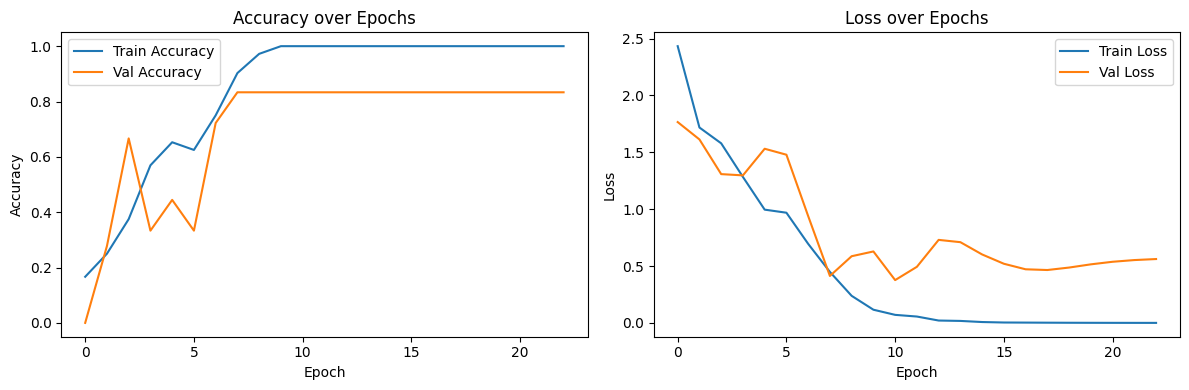

In [33]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('training_curves.png')  # save the figure
plt.show()